# Q2 — Unsupervised Learning

Segment retail customers using K-Means and visualise the segments in a 2-D PCA projection.

## 1. Data Preparation

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("../data/q2_customers.csv")
print("Shape:", data.shape)
data.head()

Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)
X_scaled_data = pd.DataFrame(X_scaled, columns=data.columns)
X_scaled_data.describe().round(2)

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,0.00,0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.56,-1.33,-1.39,-1.09,-1.00,-1.50
25%,-0.86,-0.90,-0.83,-0.86,-0.75,-0.68
50%,0.04,-0.14,-0.08,-0.28,-0.33,-0.27
75%,0.66,0.81,0.67,0.68,0.24,0.55
max,1.98,2.16,1.99,2.33,2.61,1.78


**Reasoning for applying K-means:**

In this dataset *annual_spend* ranges in the tens of thousands while *visits_per_month* and *num_categories_purchased* range in single to double digits. 
Without standardisation, the distance metric is dominated by *annual_spend* (and to a lesser extent *basket_size*) the other four features relatively contribute very little to cluster formation. Using K-Means will assign points to clusters by the Euclidean distance in the feature space. By Standard-scaling every feature to zero mean and unit variance, will put all of them on a comparable footing so K-Means can find a structure that will reflect all six parameters rather than just total spend or basket size.

## 2. Choosing K - Elbow method

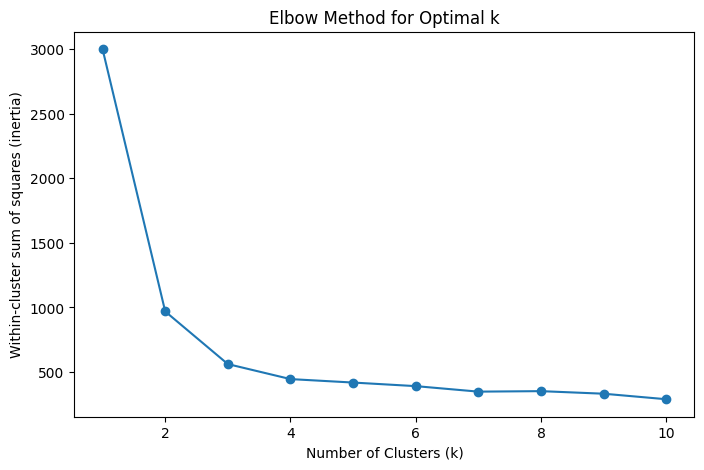

,k,wcss (inertia)
0,1,3000.0
1,2,969.0
2,3,561.3
3,4,445.0
4,5,418.2
5,6,390.5
6,7,347.9
7,8,351.7
8,9,331.8
9,10,289.1


In [19]:
from sklearn.cluster import KMeans

ks = range(1, 11)
inertia = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_data)
    inertia.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(ks), inertia, marker="o")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Within-cluster sum of squares (inertia)")
ax.set_title("Elbow Method for Optimal k")
plt.show()

pd.DataFrame({"k": list(ks), "wcss (inertia)": np.round(inertia, 1)})

The inertia curve drops steeply from K=1 to K=3 and then flattens noticeably — each additional cluster after K=3 shaves only a small amount off the WCSS. The clearest elbow therefore sits at **K = 3**. This gives an interpretable number of customer segments for the business to act on.

## 3. K-Means Clustering

In [20]:
K = 11
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

data_clustered = data.copy()
data_clustered["cluster"] = labels
data_clustered["cluster"].value_counts().sort_index()

cluster
0     44
1     22
2     92
3     40
4     38
5     32
6     78
7     47
8     38
9     35
10    34
Name: count, dtype: int64

In [21]:
centroids_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
centroids = pd.DataFrame(centroids_unscaled, columns=data.columns)
centroids.index.name = "cluster"
centroids["n_customers"] = data_clustered["cluster"].value_counts().sort_index().values
centroids.round(1)

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,n_customers
cluster,,,,,,,
0,34.7,41532.1,9.2,1879.8,36.9,3.4,44
1,58.2,100928.0,2.6,6580.9,104.2,8.1,22
2,24.5,14532.2,11.9,572.2,8.7,2.1,92
3,45.1,40716.6,7.2,2182.5,32.0,5.4,40
4,57.5,88366.9,2.6,4303.2,67.6,7.6,38
5,51.4,92623.7,2.3,3979.4,153.0,7.4,32
6,24.8,15219.2,17.2,543.4,9.5,2.2,78
7,45.3,48084.9,8.0,2050.3,32.8,3.7,47
8,61.6,84380.0,2.5,6322.0,151.4,7.5,38


**Cluster Interpretation:**

1. ***"High-Value Seniors"*** - Clusters 1, 4, 5, 8 & 9 represent the most profitable segments with significantly high "annual spend" and "basket size". However, they show relatively infrequent visits - high "days_since_last_visit". The optimal strategy would be to enroll these customers in a "Loyalty Program" and target increasing the frequency of their visits by creating a premium experience. Additional services like free delivery may also be provided since their basket sizes are high. Also important to note that clusters 5 & 8 are at risk since they have not visited in over 150 days. It might help to send them exclusive invitations with special offers.
2. ***"Young Frequent Shoppers"*** - Clusters 2 & 6 with an average age of 24-25 are highly frequent visitors and brand loyal. However, they have relatively small basket sizes and the lowest annual spends, across clusters. A good strategy for these clusters would be to cross-sell with a view to expand their basket sizes. This can be done using coupons which encourage them to spend across other categories. A subscription model with tiered benefits can also be effective. e.g. - Free delivery / coffee after every 5 purchases above a certain amount. Gamification of this through a digital app can also ensure that their engagement is sustained.
3. ***"The Core Customer"*** - Clusters 0, 3, 7 & 10 represent middle-aged customers who are the "bread & butter" of the business. They have moderate yet consistent annual spends and basket sizes. They also visit at a healthy frequency. Family-oriented marketing with family-sized bundling of products and seasonal promotions like "Diwali Bonanzas", "Back to School promos", etc. can increase spends and basket sizes. Also, referral programs with incentives will work best with these clusters since they are stable customers.

***Immediate Attention :*** Clusters 5 & 8 are at risk of churn and need to be retained. I would recommend sending out personalized promotional invites with discount vouchers to bring them back. These are a total of 70 customers which can be targeted easily with this strategy

***Long-Term Growth Focus :*** Cluster 2 & 6 (total of 170 customers) have the highest frequency of visits. Increasing their basket size by even a small margin - 10% can have a significant impact.


## 4. Dimensionality Reduction with PCA

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

evr = pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"])
print("Explained variance ratio:")
print(evr.round(3))
print(f"Cumulative: {evr.sum():.3f}")

Explained variance ratio:
PC1    0.836
PC2    0.056
dtype: float64
Cumulative: 0.891


In [23]:
loadings = pd.DataFrame(
    pca.components_,
    index=["PC1", "PC2"],
    columns=data.columns,
)
loadings.round(3)

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.412,0.422,-0.410,0.412,0.379,0.414
PC2,-0.259,-0.033,0.208,-0.195,0.911,-0.140


***PC1*** shows positive loadings on "age", "annual_spend", "basket_size", "num_categories_purchased", with negative loading on "visits_per_month". Based on this PC1 represents the trade-off between Customer maturity & wealth vs their visit frequency. Hence, a high value PC1 will represent shoppers who are older, spend more with bigger basket sizes but visit infrequently. Conversely, Low or negative PC1 values would represent younger shoppers who may visit frequently but spend lesser across smaller basket sizes.

***PC2*** is dominated by a single parameter - days_since_last_visit. In contrast the annual_spend loading is close to zero. The other parameters are also closer to zero or negative. This tells me that this component is focused on how long it has been since the customer has engaged irrespective of spend or basket size or age. Hence, high PC2 scores would indicate "At-risk" customers likely to churn, whereas low PC2 scores would indicate more "Actively engaged" customers.

## 5. Cluster Visualisation

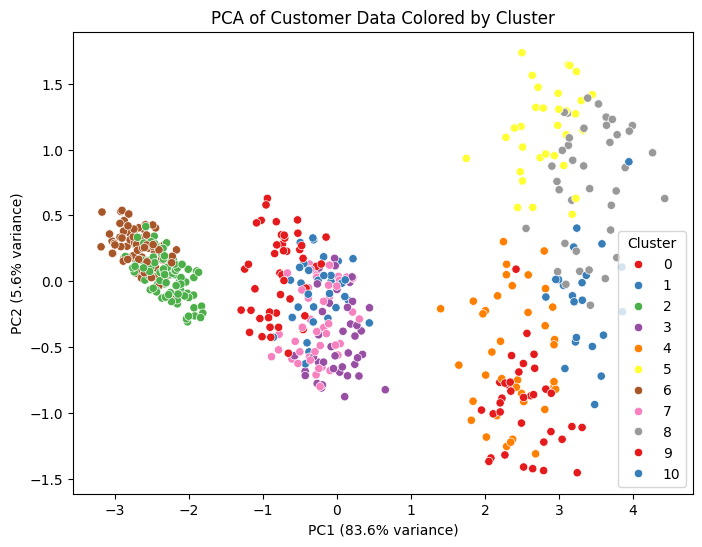

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data_clustered["cluster"], palette="Set1", ax=ax)
ax.set_xlabel(f"PC1 ({evr['PC1']:.1%} variance)")
ax.set_ylabel(f"PC2 ({evr['PC2']:.1%} variance)")
ax.set_title("PCA of Customer Data Colored by Cluster")
ax.legend(title="Cluster", loc="best")
plt.show()